<a href="https://colab.research.google.com/github/priya8667484-creator/SecureCheck-A-Python-SQL-Digital-Ledger-for-Police-Post-Logs/blob/main/Police_sql_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3

conn_sqlite = sqlite3.connect("traffic_stops.db")  # Creates a local database file
cursor = conn_sqlite.cursor()
print("SQLite connection established!")

SQLite connection established!


In [ ]:
import sqlite3

# This will create the database file if it doesn't exist
conn = sqlite3.connect('traffic_stops.db')
cursor = conn.cursor()

print("Database traffic_stops created successfully!")

Database traffic_stops created successfully!


In [ ]:
cursor.execute("""
 CREATE TABLE IF NOT EXISTS traffic_stops (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    stop_date TEXT,
    stop_time TEXT,
    country_name VARCHAR(100),
    driver_gender VARCHAR(20),
    driver_age_raw INTEGER,
    driver_age INTEGER,
    driver_race VARCHAR(50),
    violation VARCHAR(100),
    violation_raw VARCHAR(200),
    search_conducted INTEGER,
    search_type VARCHAR(100),
    stop_outcome VARCHAR(50),
    is_arrested INTEGER,
    stop_duration VARCHAR(50),
    drugs_related_stop INTEGER,
    vehicle_plate VARCHAR(30),
    officer_id VARCHAR(50),
    needs_review INTEGER,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
 );
""")
conn.commit()
print("Table 'traffic_stops' created successfully in SQLite!")

Table 'traffic_stops' created successfully in SQLite!


In [ ]:
df=pd.read_excel("traffic_stops.xlsx")

In [ ]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///traffic_stops") # Connect to the SQLite database
df.to_sql("traffic_stops", engine, if_exists="append", index=False)
print("Data inserted using to_sql()")

Data inserted using to_sql()


🚗 Vehicle-Based
    
     1.What are the top 10 vehicle_Number involved in drug-related stops?


In [ ]:
import sqlite3
conn_traffic_stops = sqlite3.connect('traffic_stops') # Re-establish connection to the correct database
cur_traffic_stops = conn_traffic_stops.cursor()

# Get and print column names
cur_traffic_stops.execute("PRAGMA table_info(traffic_stops)")
columns_info = cur_traffic_stops.fetchall()
column_names = [col[1] for col in columns_info]
print("Columns in 'traffic_stops' table:", column_names)

cur_traffic_stops.execute("""select vehicle_number,count(*) as vehicle_count from traffic_stops
where drugs_related_stop=1
group by vehicle_number
order by vehicle_count desc
limit 10""")

a=cur_traffic_stops.fetchall()  #Fetches all rows returned by the last SQL query executed by cur.
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur_traffic_stops.description],tablefmt='pumysql'))

conn_traffic_stops.close() # Close the connection after use

Columns in 'traffic_stops' table: ['stop_date', 'stop_time', 'country_name', 'driver_gender', 'driver_age_raw', 'driver_age', 'driver_race', 'violation_raw', 'violation', 'search_conducted', 'search_type', 'stop_outcome', 'is_arrested', 'stop_duration', 'drugs_related_stop', 'vehicle_number']
vehicle_number      vehicle_count
----------------  ---------------
WB99ZF2775                      1
WB99YI8937                      1
WB99XI9360                      1
WB99WX8513                      1
WB99WP1953                      1
WB99WL3205                      1
WB99WE9606                      1
WB99VP9568                      1
WB99VN3754                      1
WB99VD8787                      1


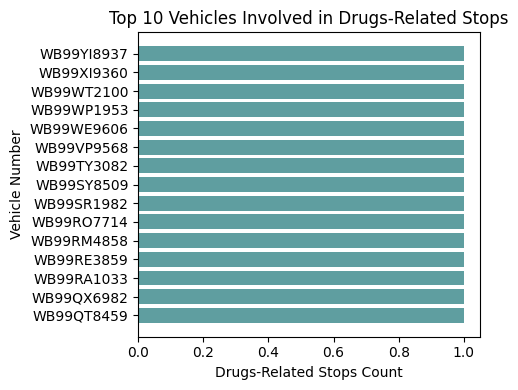

In [ ]:
vehicle_numbers = [row[0] for row in a]
counts = [row[1] for row in a]

plt.figure(figsize=(5,4))
plt.barh(vehicle_numbers, counts, color='cadetblue') #horizondal bar chart
plt.xlabel('Drugs-Related Stops Count')
plt.ylabel('Vehicle Number')
plt.title('Top 10 Vehicles Involved in Drugs-Related Stops')
plt.gca().invert_yaxis()  # puts highest count at top
plt.tight_layout() #Adjusts layout to prevent labels or title from overlapping.
plt.show()

2. Which vehicles were most frequently searched?

In [ ]:
import sqlite3

conn_traffic_stops = sqlite3.connect('traffic_stops') # Connect to the traffic_stops database
cur_traffic_stops = conn_traffic_stops.cursor()

cur_traffic_stops.execute("""select vehicle_number,count(*) as most_frequent_search_count
from traffic_stops
where search_conducted = 1
group by vehicle_number
order by most_frequent_search_count desc
limit 15""")

a=cur_traffic_stops.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur_traffic_stops.description],tablefmt='mysql'))

conn_traffic_stops.close() # Close the connection after use

vehicle_number      most_frequent_search_count
----------------  ----------------------------
WB99YI8937                                   1
WB99XI9360                                   1
WB99WT2100                                   1
WB99WP1953                                   1
WB99WE9606                                   1
WB99VP9568                                   1
WB99TY3082                                   1
WB99SY8509                                   1
WB99SR1982                                   1
WB99RO7714                                   1
WB99RM4858                                   1
WB99RE3859                                   1
WB99RA1033                                   1
WB99QX6982                                   1
WB99QT8459                                   1


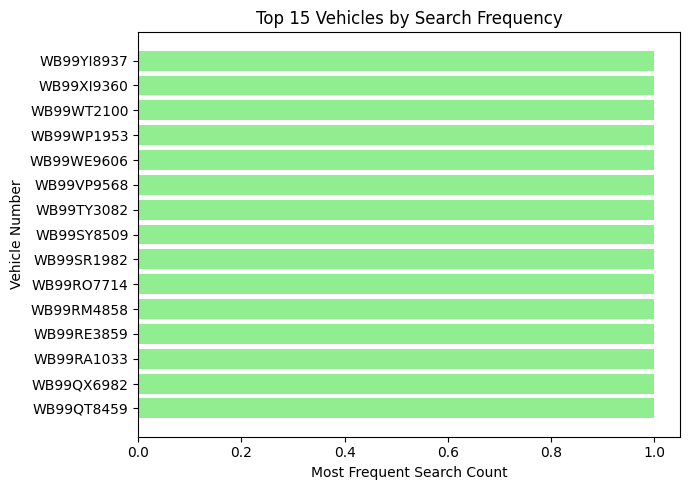

In [ ]:
#Visualization
vehicle_numbers = [row[0] for row in a]
search_counts = [row[1] for row in a]

plt.figure(figsize=(7, 5))
plt.barh(vehicle_numbers, search_counts, color='lightgreen')
plt.xlabel('Most Frequent Search Count')
plt.ylabel('Vehicle Number')
plt.title('Top 15 Vehicles by Search Frequency')
plt.gca().invert_yaxis()  # Highest on top
plt.tight_layout()
plt.show()

Demographic-Based

Driver age group had the highest arrest rate

In [ ]:
import sqlite3
import pandas as pd

df = pd.read_excel("traffic_stops.xlsx")

conn = sqlite3.connect("traffic.db")
df.to_sql("traffic_stops", conn, index=False, if_exists="replace")

conn.close()

  min_age    max_age
---------  ---------
       18         80


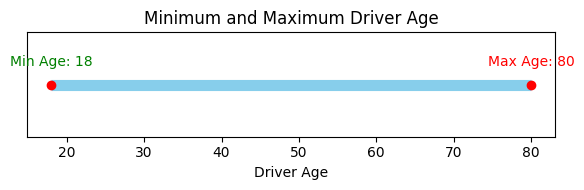

In [ ]:
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('traffic.db') # Connect to the traffic.db database
cur = conn.cursor()

cur.execute("""select min(driver_age) as min_age,
max(driver_age) as max_age
from traffic_stops""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

#Visualization
min_age, max_age = a[0]

plt.figure(figsize=(6, 2))
plt.hlines(1, min_age, max_age, color='skyblue', linewidth=8) #horizondal line
plt.plot([min_age, max_age], [1, 1], 'ro')
plt.text(min_age, 1.02, f'Min Age: {min_age}', ha='center', color='green')
plt.text(max_age, 1.02, f'Max Age: {max_age}', ha='center', color='red')
plt.yticks([]) #Removes the Y-axis ticks since they are unnecessary for this single-line visualization.
plt.xlabel('Driver Age')
plt.title('Minimum and Maximum Driver Age')
plt.tight_layout()
plt.show()

conn.close() # Close the connection after use

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Connect to the traffic.db database
cur = conn.cursor()

cur.execute("""select case
    when driver_age between 18 and 25 then '18-25'
    when driver_age between 26 and 35 then '26-35'
    when driver_age between 36 and 45 then '36-45'
    when driver_age between 46 and 60 then '46-60'
    else '60+'
end as age_group,

count(*) as total_stops,
count(case when is_arrested = 1 then 1 end) as arrests,
round(cast(count(case when is_arrested = 1 then 1 end) as REAL)/count(*)*100.0,2) as arrest_rate

from traffic_stops
group by age_group
order by arrest_rate desc limit 5""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

age_group      total_stops    arrests    arrest_rate
-----------  -------------  ---------  -------------
18-25                 8137       4171          51.26
26-35                10374       5259          50.69
60+                  20869      10423          49.94
46-60                15662       7787          49.72
36-45                10496       5206          49.6


5. What is the gender distribution of drivers stopped in each country?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select country_name,count(case when driver_gender='M' then 1 end) as MALE,
count(case when driver_gender='F' then 1 end) as FEMALE
from traffic_stops
group by country_name """)

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

country_name      MALE    FEMALE
--------------  ------  --------
Canada           10911     10997
India            10955     11043
USA              10791     10841


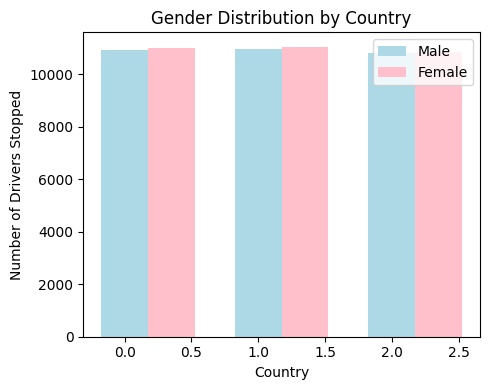

In [ ]:
#Visualization
countries = [row[0] for row in a]
male_counts = [row[1] for row in a]
female_counts = [row[2] for row in a]

x = np.arange(len(countries))  # positions for countries
bar_width = 0.35

plt.figure(figsize=(5, 4))
plt.bar(x, male_counts, width=bar_width, label='Male', color='lightblue')
plt.bar(x + bar_width, female_counts, width=bar_width, label='Female', color='pink')

plt.xlabel('Country')
plt.ylabel('Number of Drivers Stopped')
plt.title('Gender Distribution by Country')
plt.legend() #Displays a legend to differentiate male and female bars.
plt.tight_layout()
plt.show()

 6. Which race and gender combination has the highest search rate?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select driver_race, driver_gender,
round(count(case when search_conducted = 1 then 1 end) * 100.0 / count(*), 2) as search_rate
from traffic_stops
group by driver_race, driver_gender
order by search_rate DESC
limit 5
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

driver_race    driver_gender      search_rate
-------------  ---------------  -------------
Asian          F                        51.29
Hispanic       F                        50.65
Other          F                        50.49
Asian          M                        50.12
Hispanic       M                        49.88


🕒 Time & Duration Based

 7. What time of day sees the most traffic stops?


In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select substr(stop_time, 1, 2) as hour_of_the_day,count(*) as stop_count
from traffic_stops
group by hour_of_the_day
order by stop_count DESC
limit 15
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

  hour_of_the_day    stop_count
-----------------  ------------
               11          2760
               10          2760
               09          2760
               08          2760
               07          2760
               06          2760
               05          2760
               04          2760
               03          2760
               02          2760
               01          2760
               00          2760
               12          2718
               23          2700
               22          2700


8. What is the average stop duration for different violations?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select violation,
avg(case
        when stop_duration = '0-15 Min' then 7.5
        when stop_duration = '16-30 Min' then 23
        when stop_duration = '30+ Min' then 35
        END) as average_stop_duration
from traffic_stops
group by violation""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

violation      average_stop_duration
-----------  -----------------------
DUI                          21.7413
Other                        22.2033
Seatbelt                     21.8332
Signal                       21.7121
Speeding                     21.7945


9. Are stops during the night more likely to lead to arrests?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select
   case
        when cast(substr(stop_time, 1, 2) as INTEGER) >= 18 or cast(substr(stop_time, 1, 2) as INTEGER) < 6
        then 'NIGHT'
        else 'DAY'
    end as stop_period,
    count(*) as total_stops,
    count(case when is_arrested = 1 then 1 end) as arrests,
    round(cast(count(case when is_arrested = 1 then 1 end) as REAL)/count(*)*100.0,2) as arrest_rate_percent
from traffic_stops
group by stop_period
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

stop_period      total_stops    arrests    arrest_rate_percent
-------------  -------------  ---------  ---------------------
DAY                    32778      16557                  50.51
NIGHT                  32760      16289                  49.72


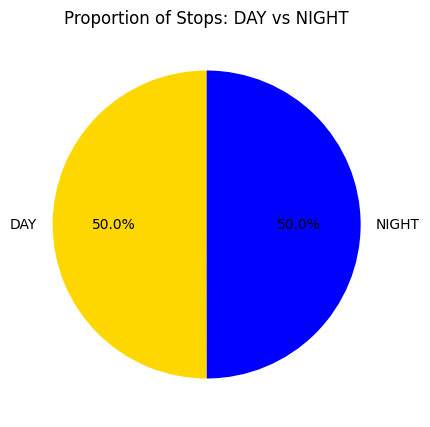

In [ ]:
#Visualization

labels = [row[0] for row in a]
sizes = [row[1] for row in a]  # Use total_stops column
colors = ['gold', 'blue']

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Proportion of Stops: DAY vs NIGHT')
plt.show()

⚖️ Violation-Based

10.Which violations are most associated with searches or arrests?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select violation,
  count(case when search_conducted=1 then 1 end) as count_of_the_search,
  count(case when is_arrested=1 then 1 end) as count_of_the_arrest,
  round(cast(count(case when search_conducted=1 then 1 end) as REAL)/count(*)*100.0,2) as search_rate,
  round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2) as arrest_rate,
  CASE
    WHEN round(cast(count(case when search_conducted=1 then 1 end) as REAL)/count(*)*100.0,2) > round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2)
    THEN round(cast(count(case when search_conducted=1 then 1 end) as REAL)/count(*)*100.0,2)
    ELSE round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2)
  END as maximum_arrest_or_search_rate
from traffic_stops
group by violation
order by maximum_arrest_or_search_rate desc limit 8
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

violation      count_of_the_search    count_of_the_arrest    search_rate    arrest_rate    maximum_arrest_or_search_rate
-----------  ---------------------  ---------------------  -------------  -------------  -------------------------------
DUI                           6481                   6610          49.57          50.55                            50.55
Seatbelt                      6562                   6573          50.45          50.53                            50.53
Speeding                      6573                   6598          49.98          50.17                            50.17
Signal                        6509                   6549          49.64          49.95                            49.95
Other                         6576                   6516          49.84          49.39                            49.84


11. Violations are most common among younger drivers (<25)

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select violation,count(*) as counts_of_driver from traffic_stops
where driver_age<25
group by violation
order by counts_of_driver desc limit 1
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

violation      counts_of_driver
-----------  ------------------
Speeding                   1476


12. Is there a violation that rarely results in search or arrest?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select violation,
  count(case when search_conducted=1 then 1 end) as count_of_the_search,
  count(case when is_arrested=1 then 1 end) as count_of_the_arrest,
  round(cast(count(case when search_conducted=1 then 1 end) as REAL)/count(*)*100.0,2) as search_rate,
  round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2) as arrest_rate,
  CASE
    WHEN round(cast(count(case when search_conducted=1 then 1 end) as REAL)/count(*)*100.0,2) < round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2)
    THEN round(cast(count(case when search_conducted=1 then 1 end) as REAL)/count(*)*100.0,2)
    ELSE round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2)
  END as rarely_arrest_or_search_rate
from traffic_stops
group by violation
order by rarely_arrest_or_search_rate asc limit 1
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

violation      count_of_the_search    count_of_the_arrest    search_rate    arrest_rate    rarely_arrest_or_search_rate
-----------  ---------------------  ---------------------  -------------  -------------  ------------------------------
Other                         6576                   6516          49.84          49.39                           49.39


🌍 Location-Based

13.Which countries report the highest rate of drug-related stops?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select country_name,
count(*) as tot_counts,
round(cast(count(case when drugs_related_stop=1 then 1 end) as REAL)/count(*)*100.0,2) as drugs_related_stop_rates
from traffic_stops
group by country_name
order by drugs_related_stop_rates desc
limit 3""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

country_name      tot_counts    drugs_related_stop_rates
--------------  ------------  --------------------------
USA                    21632                       50.37
Canada                 21908                       50.1
India                  21998                       49.54


14. What is the arrest rate by country and violation?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select country_name,violation,
count(*) as tot_count,
round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2) as arrest_rate
from traffic_stops
group by country_name,violation""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

country_name    violation      tot_count    arrest_rate
--------------  -----------  -----------  -------------
Canada          DUI                 4414          51.13
Canada          Other               4371          50.29
Canada          Seatbelt            4421          50.46
Canada          Signal              4327          49.18
Canada          Speeding            4375          49.94
India           DUI                 4420          50.84
India           Other               4431          49.29
India           Seatbelt            4345          50.56
India           Signal              4444          50.65
India           Speeding            4358          50.76
USA             DUI                 4241          49.66
USA             Other               4392          48.59
USA             Seatbelt            4241          50.58
USA             Signal              4341          49.99
USA             Speeding            4417          49.83


15.Which country has the most stops with search conducted?

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select country_name,violation,
count(*) as tot_count,
round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100.0,2) as arrest_rate
from traffic_stops
group by country_name,violation""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

country_name    violation      tot_count    arrest_rate
--------------  -----------  -----------  -------------
Canada          DUI                 4414          51.13
Canada          Other               4371          50.29
Canada          Seatbelt            4421          50.46
Canada          Signal              4327          49.18
Canada          Speeding            4375          49.94
India           DUI                 4420          50.84
India           Other               4431          49.29
India           Seatbelt            4345          50.56
India           Signal              4444          50.65
India           Speeding            4358          50.76
USA             DUI                 4241          49.66
USA             Other               4392          48.59
USA             Seatbelt            4241          50.58
USA             Signal              4341          49.99
USA             Speeding            4417          49.83


(Complex):

1.Yearly Breakdown of Stops and Arrests by Country (Using Subquery and Window Functions)

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select country_name,
count(case when search_conducted=1 then 1 end) as no_of_counts
from traffic_stops
group by country_name
order by no_of_counts desc
limit 3""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

country_name      no_of_counts
--------------  --------------
Canada                   11020
India                    10959
USA                      10722


2.Driver Violation Trends Based on Age and Race (Join with Subquery)

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select
    age_info.age_group,
    r.driver_race,
    count(*) as total_violations
from traffic_stops r
join(
    select distinct
        driver_age,
        case
            when driver_age between 16 and 25 then '16-25'
            when driver_age between 26 and 35 then '26-35'
            when driver_age between 36 and 50 then '36-50'
            when driver_age>50 then '51+'
            else 'Unknown'
        end as age_group from traffic_stops)as age_info on r.driver_age=age_info.driver_age
group by age_info.age_group, r.driver_race
order by age_info.age_group, r.driver_race;
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

age_group    driver_race      total_violations
-----------  -------------  ------------------
16-25        Asian                        1587
16-25        Black                        1670
16-25        Hispanic                     1605
16-25        Other                        1648
16-25        White                        1627
26-35        Asian                        2127
26-35        Black                        2073
26-35        Hispanic                     2084
26-35        Other                        2058
26-35        White                        2032
36-50        Asian                        3140
36-50        Black                        3100
36-50        Hispanic                     3131
36-50        Other                        3164
36-50        White                        3155
51+          Asian                        6257
51+          Black                        6288
51+          Hispanic                     6186
51+          Other                        6252
51+          

3.Time Period Analysis of Stops (Joining with Date Functions) , Number of Stops by Year,Month, Hour of the Day

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""SELECT
strftime('%Y', substr(stop_date, 7, 4) || '-' || substr(stop_date, 4, 2) || '-' || substr(stop_date, 1, 2)) AS STOP_YEAR,
strftime('%m', substr(stop_date, 7, 4) || '-' || substr(stop_date, 4, 2) || '-' || substr(stop_date, 1, 2)) AS STOP_MONTH,
strftime('%H', stop_time) AS STOP_HOUR,
count(*) AS total_stops
FROM traffic_stops
group by STOP_YEAR,STOP_MONTH,STOP_HOUR
order by STOP_YEAR,STOP_MONTH,STOP_HOUR
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

  STOP_YEAR    STOP_MONTH    STOP_HOUR    total_stops
-----------  ------------  -----------  -------------
       2020            01           00           1860
       2020            01           01           1860
       2020            01           02           1860
       2020            01           03           1860
       2020            01           04           1860
       2020            01           05           1860
       2020            01           06           1860
       2020            01           07           1860
       2020            01           08           1860
       2020            01           09           1860
       2020            01           10           1860
       2020            01           11           1860
       2020            01           12           1860
       2020            01           13           1860
       2020            01           14           1860
       2020            01           15           1860
       2020            01   

4.Violations with High Search and Arrest Rates (Window Function)

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select * from(select distinct violation,
count(*) over(partition by violation) as total_stops,
sum(case when search_conducted=1 then 1 else 0 end) over(partition by violation) as total_searches,
sum(case when is_arrested=1 then 1 else 0 end) over(partition by violation) as total_arrests,
round(avg(case when search_conducted=1 then 1 else 0 end) over(partition by violation)*100,2) as search_rate_percent,
round(avg(case when is_arrested=1 then 1 else 0 end) over(partition by violation)*100,2) as arrest_rate_percent
from traffic_stops
)as sub
where search_rate_percent>20 or arrest_rate_percent>20
order by search_rate_percent desc,arrest_rate_percent desc
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

violation      total_stops    total_searches    total_arrests    search_rate_percent    arrest_rate_percent
-----------  -------------  ----------------  ---------------  ---------------------  ---------------------
Seatbelt             13007              6562             6573                  50.45                  50.53
Speeding             13150              6573             6598                  49.98                  50.17
Other                13194              6576             6516                  49.84                  49.39
Signal               13112              6509             6549                  49.64                  49.95
DUI                  13075              6481             6610                  49.57                  50.55


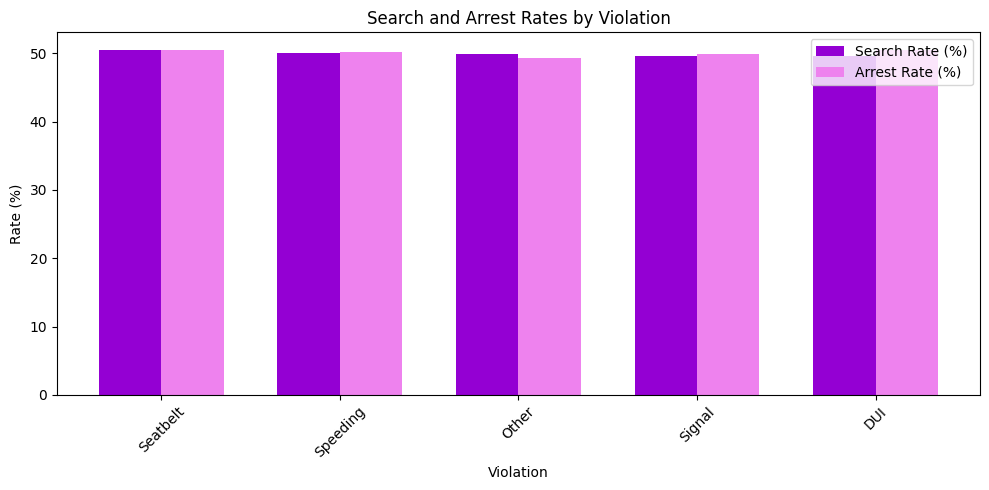

In [ ]:
#Visualization
violations = [row[0] for row in a]
search_rate_percent = [row[4] for row in a]
arrest_rate_percent = [row[5] for row in a]

x = np.arange(len(violations))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x, search_rate_percent, width, label='Search Rate (%)', color='darkviolet')
plt.bar(x + width, arrest_rate_percent, width, label='Arrest Rate (%)', color='violet')

plt.xlabel('Violation')
plt.ylabel('Rate (%)')
plt.title('Search and Arrest Rates by Violation')
plt.xticks(x + width / 2, violations, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

5.Driver Demographics by Country (Age, Gender, and Race)

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select driver_race from traffic_stops group by driver_race""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

driver_race
-------------
Asian
Black
Hispanic
Other
White


In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select driver_age from traffic_stops group by driver_age""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

  driver_age
------------
          18
          19
          20
          21
          22
          23
          24
          25
          26
          27
          28
          29
          30
          31
          32
          33
          34
          35
          36
          37
          38
          39
          40
          41
          42
          43
          44
          45
          46
          47
          48
          49
          50
          51
          52
          53
          54
          55
          56
          57
          58
          59
          60
          61
          62
          63
          64
          65
          66
          67
          68
          69
          70
          71
          72
          73
          74
          75
          76
          77
          78
          79
          80


In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select country_name,count(*) as tot_driver,
count(case when driver_gender='M' then 1 end) as Male_driver,
count(case when driver_gender='F' then 1 end) as Female_driver,
count(case when driver_race='Asian' then 1 end) as Asian_driver,
count(case when driver_race='Black' then 1 end) as Black_driver,
count(case when driver_race='Hispanic' then 1 end) as Hispanic_driver,
count(case when driver_race='Other' then 1 end) as Other_people,
count(case when driver_race ='White' then 1 end) as White_driver,
count(case when driver_age<30 then 1 end) as less_than_thirty,
count(case when driver_age between 30 and 50 then 1 end) as between_thirty_and_fifty,
count(case when driver_age>50 then 1 end) as greater_than_fifty
from traffic_stops
group by country_name""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

country_name      tot_driver    Male_driver    Female_driver    Asian_driver    Black_driver    Hispanic_driver    Other_people    White_driver    less_than_thirty    between_thirty_and_fifty    greater_than_fifty
--------------  ------------  -------------  ---------------  --------------  --------------  -----------------  --------------  --------------  ------------------  --------------------------  --------------------
Canada                 21908          10911            10997            4344            4342               4395            4398            4429                4177                        7254                 10477
India                  21998          10955            11043            4451            4418               4406            4377            4346                4124                        7355                 10519
USA                    21632          10791            10841            4316            4371               4205            4347            4393 

6.Top 5 Violations with Highest Arrest Rates

In [ ]:
import sqlite3

conn = sqlite3.connect('traffic.db') # Establish connection to the correct database
cur = conn.cursor()

cur.execute("""select violation,count(*) as total,
round(cast(count(case when is_arrested=1 then 1 end) as REAL)/count(*)*100,2) as arrest_rate
from traffic_stops
group by violation
order by arrest_rate desc limit 5
""")

a=cur.fetchall()
from tabulate import tabulate
print(tabulate(a,headers=[i[0] for i in cur.description],tablefmt='mysql'))

conn.close() # Close the connection after use

violation      total    arrest_rate
-----------  -------  -------------
DUI            13075          50.55
Seatbelt       13007          50.53
Speeding       13150          50.17
Signal         13112          49.95
Other          13194          49.39


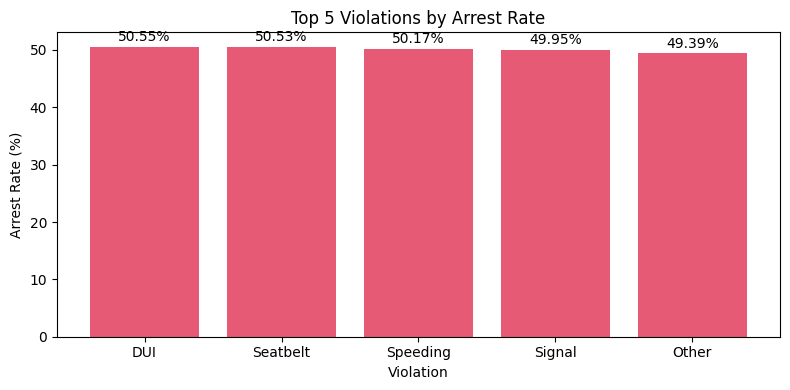

In [ ]:
#Visualization
violations = [row[0] for row in a]
totals = [row[1] for row in a]
arrest_rates = [row[2] for row in a]

plt.figure(figsize=(8,4))
bars = plt.bar(violations, arrest_rates, color='crimson', alpha=0.7)
plt.xlabel('Violation')
plt.ylabel('Arrest Rate (%)')
plt.title('Top 5 Violations by Arrest Rate')

# Annotate each bar with its percentage
for bar, rate in zip(bars, arrest_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{rate}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()